In [ ]:
import numpy as np
import pandas as pd

In [ ]:
split_csv_file ="/mnt/Enterprise2/AI-Sarosh/datasets/csvs/train/data.csv" 
patient_label_csv_file="/mnt/Enterprise2/AI-Sarosh/datasets/csvs/train/labels_study.csv"

data_df = pd.read_csv(split_csv_file)
labels_df = pd.read_csv(patient_label_csv_file)

merged_df = pd.merge(data_df, labels_df, on=['PatientID', 'StudyInstanceUID'])[['PatientID', 'StudyInstanceUID','fname', 'placenta', 'presentation']]

data_arr = merged_df.groupby(['PatientID','StudyInstanceUID','placenta', 'presentation'],as_index = False)[['fname']]

In [ ]:
data_np=[{"meta":np.array(p_key), "files":data.to_numpy()} for (p_key,data) in list(data_arr)]

In [ ]:
list(data_arr)[0]

In [ ]:
data_np

In [ ]:
merged_df

In [ ]:
from pathlib import Path
from typing import Any, Callable, Sequence

import numpy as np
import pandas as pd
import torch
from monai.config.type_definitions import PathLike
from monai.transforms import Compose, LoadImaged, Resized, ToTensord, EnsureChannelFirstd, PadListDataCollate, Cropd, Crop
from torch.nn import functional as TF
from torch.utils.data import Dataset
import torchvision
from pydicom import dcmread
from pydicom.pixel_data_handlers import convert_color_space
from PIL import Image

: 

In [ ]:
class CropImgDropRepeatedChannels(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        image= sample['image']
        print(image.shape)
        image = image.permute( 1,3,0,2)
        print(image.shape)
        image = image[:,0,:,:]
        print("from transforms", image.shape)
        sample['image'] = image
        return sample

In [ ]:
transformd = Compose(
                [LoadImaged(keys=["image"]), CropImgDropRepeatedChannels() ]
            )

In [ ]:
split_csv_file ="/mnt/Enterprise2/AI-Sarosh/datasets/csvs/train/data.csv" 
label_csv_file="/mnt/Enterprise2/AI-Sarosh/datasets/csvs/train/labels_clip.csv"

In [ ]:
data_df = pd.read_csv(split_csv_file, index_col=0)

labels_df = pd.read_csv(label_csv_file, index_col=0)


merged_df = pd.merge(data_df, labels_df, on=['PatientID', 'StudyInstanceUID','fname'])[['fname', 'PatientID', 'StudyInstanceUID', 'placenta', 'presentation']]
data_arr = merged_df.to_numpy()

In [ ]:
data_dict = [{
    "image": data_arr[0, 0],
    "fname": data_arr[0, 0],
    "patient": data_arr[0,1],
    "instance":f"{data_arr[0,2]}_{str(data_arr[0, 0]).split('/')[-1].split('.')[0]}",
    "placenta": data_arr[0, 3],
    "presentation": data_arr[0, 4],
    
    
    # ".split("/")[-1]).split(".")[0]}"
# }, {    "image": data_arr[1, 0],
#     "fname": data_arr[1, 0],
#     "patient": data_arr[1,1],
#     "instance":f"{data_arr[1,2]}_{str(data_arr[1, 0]).split('/')[-1].split('.')[1]}",
#     "placenta": data_arr[1, 3],
#     "presentation": data_arr[1, 4],}
}]

In [ ]:
data_dict

In [ ]:
data_final = transformd(data_dict)

In [ ]:

torchvision.transforms.functional.to_pil_image(data_final[0]['image'][0,:,:]*255)

In [15]:
from pathlib import Path
from typing import Any, Callable, Sequence
from pydicom import dcmread
import numpy as np
import pandas as pd
import torch
from monai.config.type_definitions import PathLike
from monai.transforms import Compose, LoadImaged, Resized, ToTensord
from torch.nn import functional as TF
from torch.utils.data import Dataset
import torchvision

In [7]:
image_root_dir = Path('/home/kanchan')
split_csv_file = "/mnt/Enterprise2/AI-Sarosh/datasets/famli_csvs/merged-all.csv"
task="us_plac"
merged_df = pd.read_csv(split_csv_file)
        
data_arr = merged_df.groupby(['study_id','pid',f'{task}'],as_index = False)[['file_path']]
data_arr = [{"meta":np.array(p_key), "files":data.to_numpy()} for (p_key,data) in list(data_arr)]

In [8]:
data_dict = {
            "fnames": data_arr[0]['files'],
            "study": data_arr[0]['meta'][0],
            "patient": data_arr[0]['meta'][1],
            f"{task}": data_arr[0]['meta'][2],
        }
        

In [9]:
data_dict

{'fnames': array([['ivf_test/UNC-0069-2/1.3.6.1.4.1.35190.4.1.20210603.171729024599'],
        ['ivf_test/UNC-0069-2/1.3.6.1.4.1.35190.4.1.20210603.302057061133'],
        ['ivf_test/UNC-0069-2/1.3.6.1.4.1.35190.4.1.20210603.447789456902'],
        ['ivf_test/UNC-0069-2/1.3.6.1.4.1.35190.4.1.20210603.493485651340'],
        ['ivf_test/UNC-0069-2/1.3.6.1.4.1.35190.4.1.20210603.596877475526'],
        ['ivf_test/UNC-0069-2/1.3.6.1.4.1.35190.4.1.20210603.776234057248']],
       dtype=object),
 'study': 'UNC-0069-2',
 'patient': 'UNC-0069',
 'us_plac': 'Anterior'}

/home/kanchan/.local/lib/python3.10/site-packages/pydicom/valuerep.py:440: UserWarning: The value length (124) exceeds the maximum length of 64 allowed for VR LO.
  warn_and_log(msg)


Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Ultrasound Multi-frame Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.35190.4.1.20210603.302057061133
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.1
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_361'
(0002,0016) Source Application Entity Title     AE: 'FAMLI'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'OBSTETRICAL', '']
(0008,0016) SOP Class UID                       UI: Ultrasound Multi-frame Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1

In [13]:
img = dcmread('/home/kanchan/ivf_test/UNC-0069-2/1.3.6.1.4.1.35190.4.1.20210603.302057061133').pixel_array

In [40]:
img.shape

(359, 735, 975, 3)

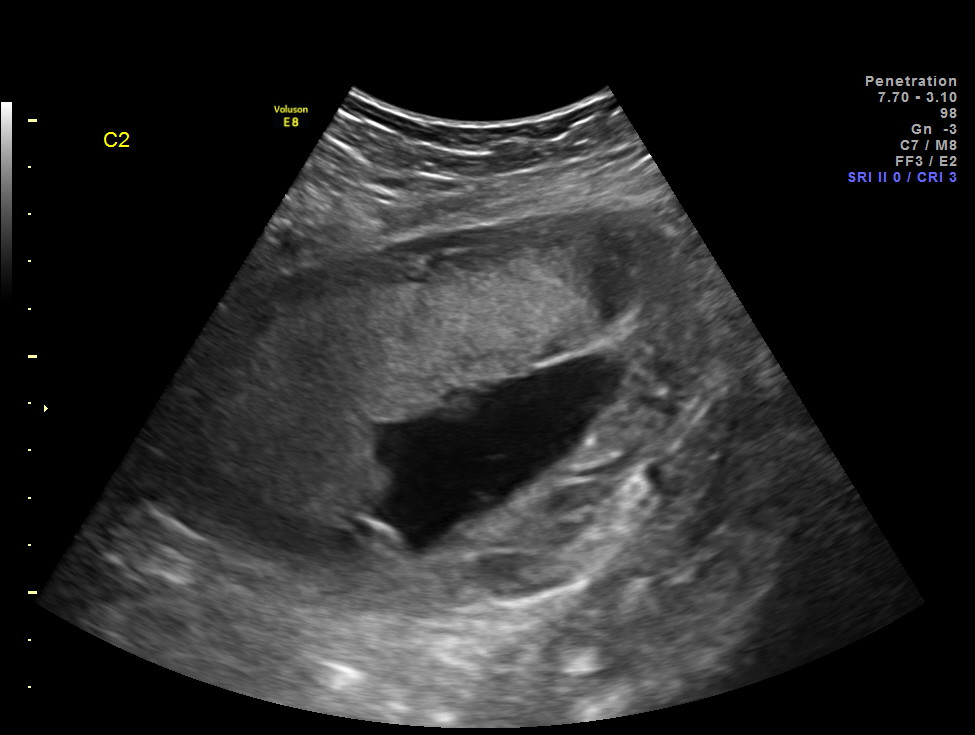

In [25]:
torchvision.transforms.functional.to_pil_image(img[0, :, :, :].reshape(735,975,3))

In [32]:
img.shape

(359, 735, 975, 3)

In [37]:
(img[:,:,:,0]).shape

(359, 735, 975)

In [39]:
torch.tensor(img[:,:,:,0]).shape

torch.Size([359, 735, 975])

In [41]:
type(img)


numpy.ndarray

In [46]:
img1 = img[:,:,:,0]

In [48]:
img2 = img[:,:,:,0]

In [49]:
img1.shape

(359, 735, 975)

In [50]:
img2.shape

(359, 735, 975)

In [54]:
np.concatenate((img1, img2), axis=0).shape

(718, 735, 975)

In [ ]:
np.concatenate((img1, img2), axis=0).shape

ValueError: zero-dimensional arrays cannot be concatenated

TypeError: cannot unpack non-iterable NoneType object

In [58]:
img.shape

(359, 735, 975, 3)

In [59]:
_,h,w,_ = img.shape

In [60]:
h

735

In [61]:
w

975